<a href="https://colab.research.google.com/github/JWasonga/Statistical_Data_Analytics/blob/Applied_Statistics_and_Econometrics-_Portfolio/2_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Avocado Price - Data cleaning & Feature Engineering

Pipeline:

1. Drop the leftover unnamed index column

2. Parse `Date` -> exact `month`, `week`

3. Rename PLU columns to readable names

4. Engineer `log_total_volume`, `log_total_bags`, `small_share`, `large_share`, `xl_share`

5. One-hot encode `type` (binary) and `region` (54 levels)

6. Save to `data/avocado_cleaned.csv`

#1. Imports and Load

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the utility functions directly in the notebook
def load_data(path):
    return pd.read_csv(path)

def drop_index_column(df):
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])
    return df

def parse_date(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int) # Using isocalendar().week for week of year
    return df

def rename_plu(df):
    df = df.rename(columns={'4046': 'Small_hass', '4225': 'Large_hass', '4770': 'XLarge_hass'})
    return df

def create_features(df):
    df['log_total_volume'] = np.log1p(df['Total Volume'])
    df['log_total_bags'] = np.log1p(df['Total Bags'])
    df['small_share'] = df['Small Bags'] / df['Total Bags'].replace(0, np.nan)
    df['large_share'] = df['Large Bags'] / df['Total Bags'].replace(0, np.nan)
    df['xl_share'] = df['XLarge Bags'] / df['Total Bags'].replace(0, np.nan)
    df = df.fillna(0) # Fill NaN values created by division by zero with 0
    return df

def preprocess_data(df):
    df = drop_index_column(df)
    df = parse_date(df)
    df = rename_plu(df)
    df = create_features(df)
    return df

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [7]:
from google.colab import files
uploaded = files.upload()

Saving avocado.csv to avocado.csv


In [15]:
df = pd.read_csv("avocado.csv")
print(f"Raw shape:   {df.shape}")
df.head()

Raw shape:   (18249, 14)


,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


#2. Missing / Inavlid Values

In [16]:
print(f"Missing values:  {df.isnull().sum().sum()}")
print(f"Duplicate rows:  {df.duplicated().sum()}")

Missing values:  0
Duplicate rows:  0


#3. Drop  index, parse date, rename PLU columns

In [18]:
df_step = drop_index_column(df)
df_step = parse_date(df_step)
df_step = rename_plu(df_step)
print(f"shape:  {df_step.shape}")
print(f"New columns: {[c for c in df_step.columns if c not in df.columns]}")
df_step.head()

shape:  (18249, 15)
New columns: ['Small_hass', 'Large_hass', 'XLarge_hass', 'Month', 'Week']


,Date,AveragePrice,Total Volume,Small_hass,Large_hass,XLarge_hass,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,Month,Week
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,52
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,51
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,50
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,49
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,48


#4. Feature Engineering

In [22]:
df_feat = create_features(df_step)
new_cols = [c for c in df_feat.columns if c not in df_step.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["log_total_volume","log_total_bags","small_share","large_share","xl_share","AveragePrice"]].head()

New features: []


,log_total_volume,log_total_bags,small_share,large_share,xl_share,AveragePrice
0,11.070344,9.070833,0.989278,0.010722,0.0,1.33
1,10.912867,9.159737,0.989744,0.010256,0.0,1.35
2,11.680313,9.005325,0.987338,0.012662,0.0,0.93
3,11.277116,8.667708,0.976982,0.023018,0.0,1.08
4,10.840377,8.729874,0.968032,0.031968,0.0,1.28


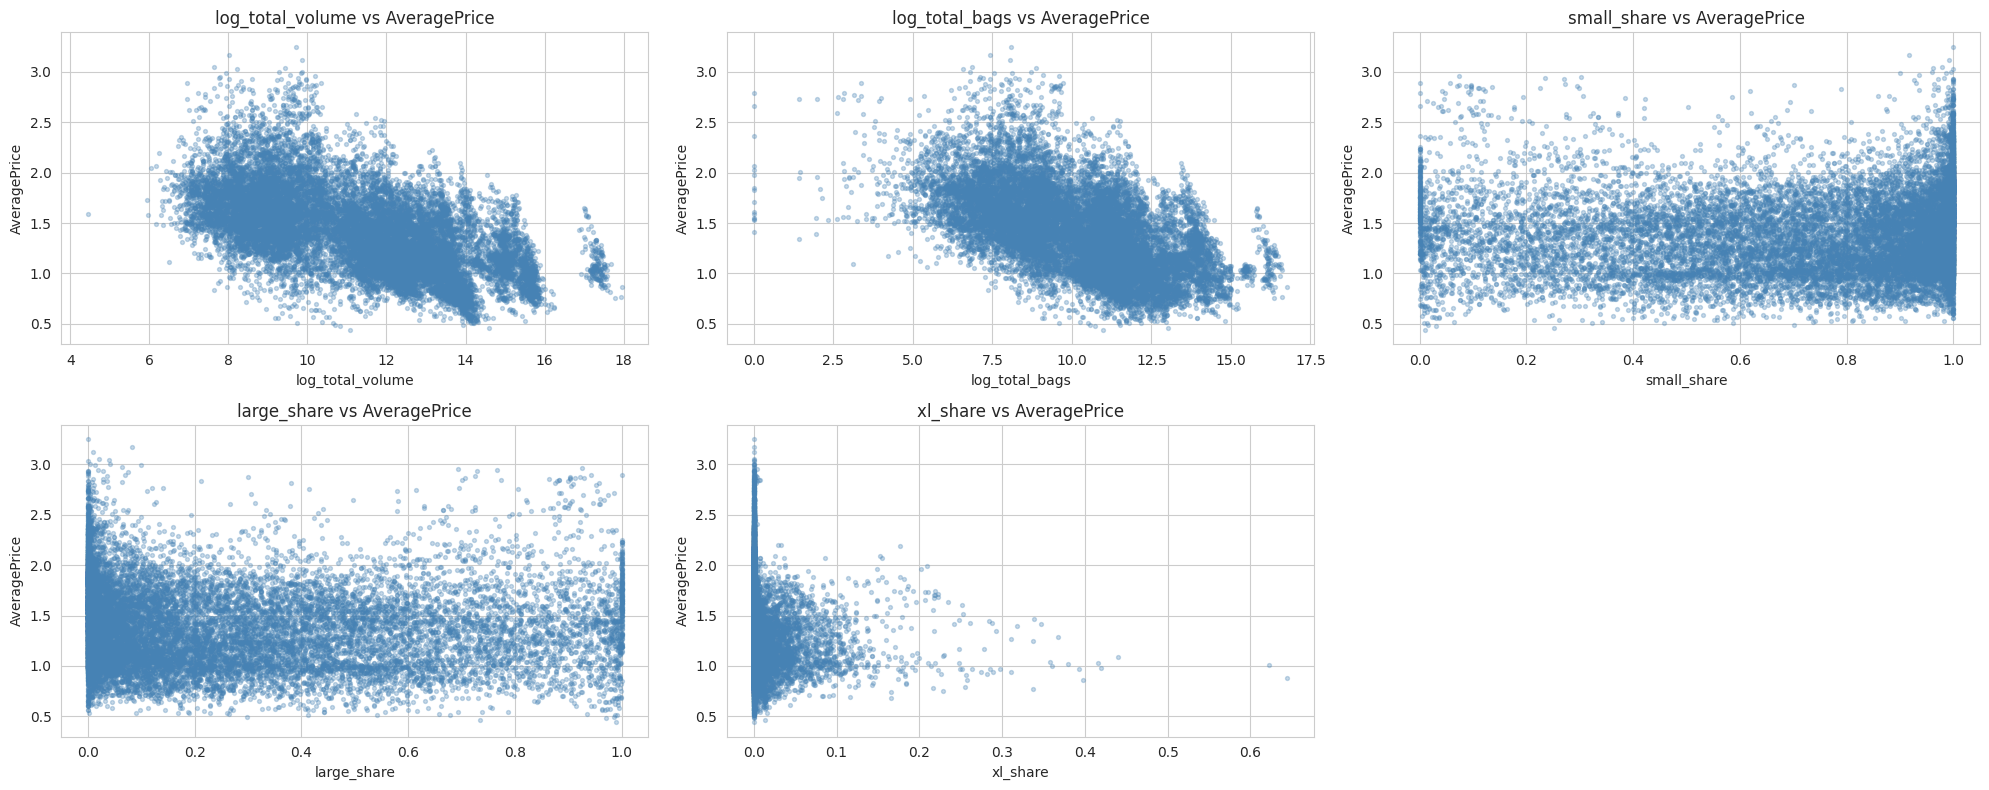

In [24]:
#Visualize transforms vs target
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
for i, col in enumerate(["log_total_volume", "log_total_bags",
                         "small_share", "large_share", "xl_share"]):
    axes[i//3, i%3].scatter(df_feat[col], df_feat["AveragePrice"], alpha=0.3, color="steelblue", s=8)
    axes[i//3, i%3].set_xlabel(col); axes[i//3, i%3].set_ylabel("AveragePrice")
    axes[i//3, i%3].set_title(f"{col} vs AveragePrice")
axes[1, 2].axis("off")
plt.tight_layout(); plt.show()


#5. Run the Full Pipeline

In [26]:
df_processed = preprocess_data(df)
print(f"Processed shape:  {df_processed.shape}")
print(f"Missing values: {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape:  (18249, 20)
Missing values: 0


,Date,AveragePrice,Total Volume,Small_hass,Large_hass,XLarge_hass,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,Month,Week,log_total_volume,log_total_bags,small_share,large_share,xl_share
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,52,11.070344,9.070833,0.989278,0.010722,0.0
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,51,10.912867,9.159737,0.989744,0.010256,0.0
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,50,11.680313,9.005325,0.987338,0.012662,0.0
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,49,11.277116,8.667708,0.976982,0.023018,0.0
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,48,10.840377,8.729874,0.968032,0.031968,0.0


#6. Sanity Checks & Save

In [29]:
assert df_processed.isnull().sum().sum() == 0
assert "AveragePrice" in df_processed.columns
print("All checks passed.")

All checks passed.


In [30]:
from google.colab import files
df_processed.to_csv('avocado_cleaned.csv', index=False)
files.download('avocado_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>